## Master Project: Segmentación Avanzada de Clientes y Estrategias de Retención
#### Fusión de Técnicas: Clustering (K-Means/DBSCAN) + Lógica de Negocio

# 3° Avance: Análisis de Segmentación y Exploración No Supervisada 
## Proyecto: Estrategias de Retención para FinanceGuard

**Rol:** Científico de Datos Junior  
**Objetivo:** Aplicar técnicas de clustering y reducción de dimensionalidad para descubrir patrones ocultos de comportamiento y diseñar estrategias para reducir el Churn (tasa de abandono del 20%).

###  Agenda del Notebook:
1.  **Preprocesamiento:** Limpieza y escalado robusto.
2.  **Reducción de Dimensionalidad (PCA):** Análisis de varianza y visualización 2D.
3.  **Segmentación (K-Means):** Definición de K óptimo y creación de perfiles.
4.  **Detección de Anomalías (DBSCAN):** Identificación de clientes atípicos (ruido).
5.  **Visualización No Lineal (t-SNE):** Validación visual de la separación de clusters.
6.  **Perfilado y Estrategia:** Análisis de Churn por segmento y recomendaciones de negocio (Motor de Estrategia).

In [146]:
# Importación de librerías del Stack Tecnológico
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning (Scikit-Learn)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Configuración de estilos
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# Carga de Datos
try:
    df = pd.read_csv('Churn_Modelling.csv')
    print("✅ Dataset cargado correctamente:", df.shape)
except FileNotFoundError:
    print("⚠️ Error: No se encuentra el archivo 'Churn_Modelling.csv'")

# Vista previa
df.head()

✅ Dataset cargado correctamente: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [147]:
# 1. Selección de Features
# Eliminamos identificadores que no aportan patrón de comportamiento
cols_drop = ['RowNumber', 'CustomerId', 'Surname', 'Exited']
df_features = df.drop(columns=cols_drop)

# 2. Encoding (One-Hot)
# Convertimos Geography y Gender a numérico
df_features = pd.get_dummies(df_features, columns=['Geography', 'Gender'], drop_first=True)

# 3. Escalado (StandardScaler)
# Crucial para algoritmos de distancia (K-Means/DBSCAN/PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# DataFrame escalado para facilitar manejo posterior
X_scaled_df = pd.DataFrame(X_scaled, columns=df_features.columns)

print("✅ Datos procesados y escalados. Dimensiones:", X_scaled.shape)
display(X_scaled_df.head(3))

✅ Datos procesados y escalados. Dimensiones: (10000, 11)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,-0.578736,-0.573809,-1.095988
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-0.578736,1.742740,-1.095988
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,-0.578736,-0.573809,-1.095988


## 🌀 1. Reducción de Dimensionalidad: PCA (Principal Component Analysis)
Antes de clusterizar, analizamos la estructura de los datos reduciendo sus dimensiones. Esto nos ayuda a visualizar la complejidad y eliminar ruido.

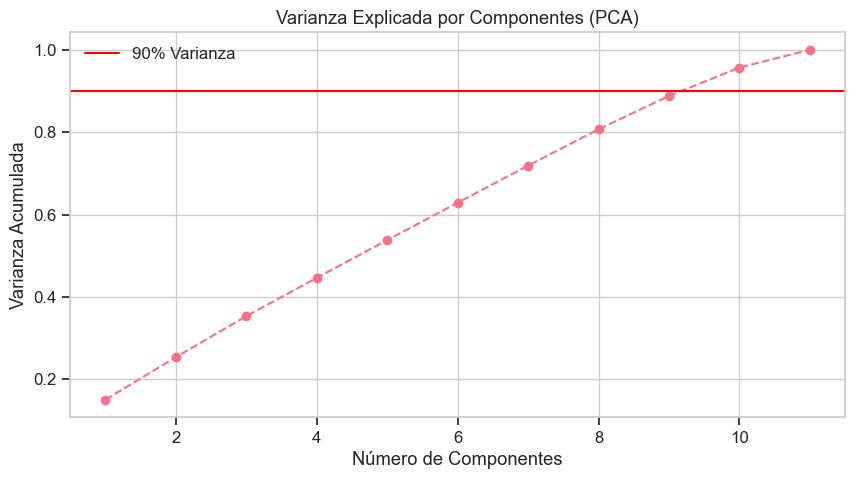

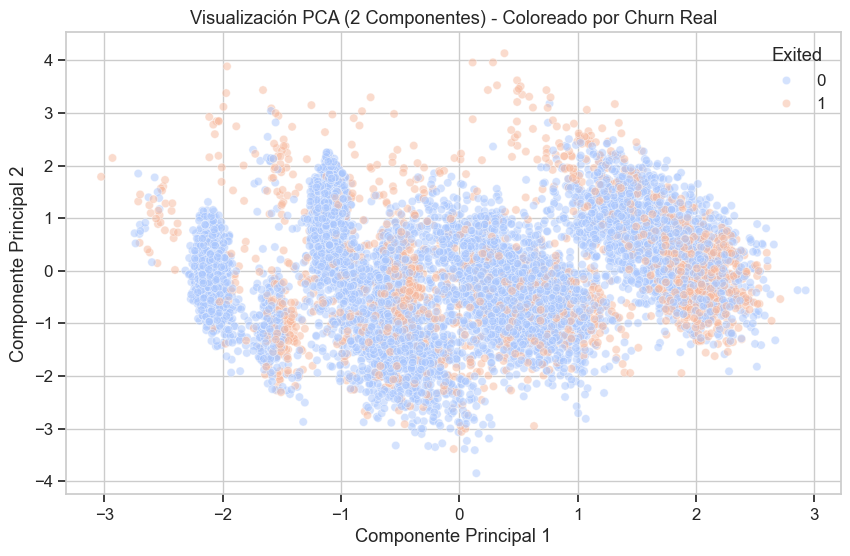

ℹ️ Varianza explicada con 2 componentes: 25.37%


In [148]:
# Entrenar PCA
pca = PCA(n_components=None) # Primero probamos con todas para ver la varianza
pca.fit(X_scaled)

# Calcular Varianza Acumulada
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# --- GRÁFICO 1: Varianza Explicada ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Varianza')
plt.title('Varianza Explicada por Componentes (PCA)')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.legend()
plt.grid(True)
plt.show()

# Aplicamos PCA con 2 componentes para visualización 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# --- GRÁFICO 2: Proyección 2D ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_2d[:,0], y=X_pca_2d[:,1], alpha=0.5, hue=df['Exited'], palette='coolwarm')
plt.title('Visualización PCA (2 Componentes) - Coloreado por Churn Real')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

print(f"ℹ️ Varianza explicada con 2 componentes: {sum(pca_2d.explained_variance_ratio_):.2%}")

## 🎯 2. Segmentación de Clientes: K-Means
Utilizamos el **Método del Codo** y la **Silueta** para determinar el número óptimo de segmentos (K).

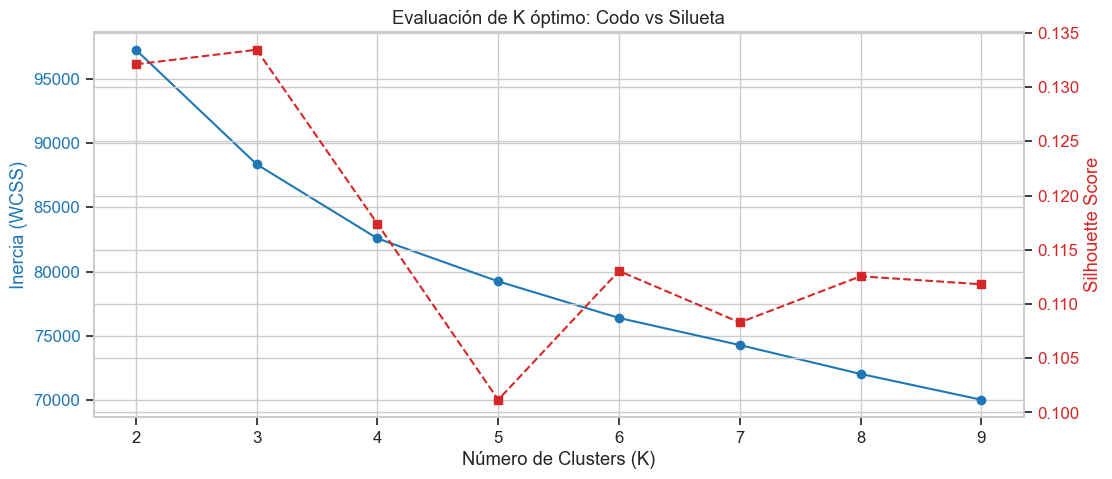

In [149]:
wcss = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Gráficos de decisión
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Inercia (Codo)
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia (WCSS)', color='tab:blue')
ax1.plot(k_range, wcss, marker='o', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot Silueta
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='--', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Evaluación de K óptimo: Codo vs Silueta')
plt.grid(True)
plt.show()

⏳ Calculando t-SNE (puede tardar unos segundos)...


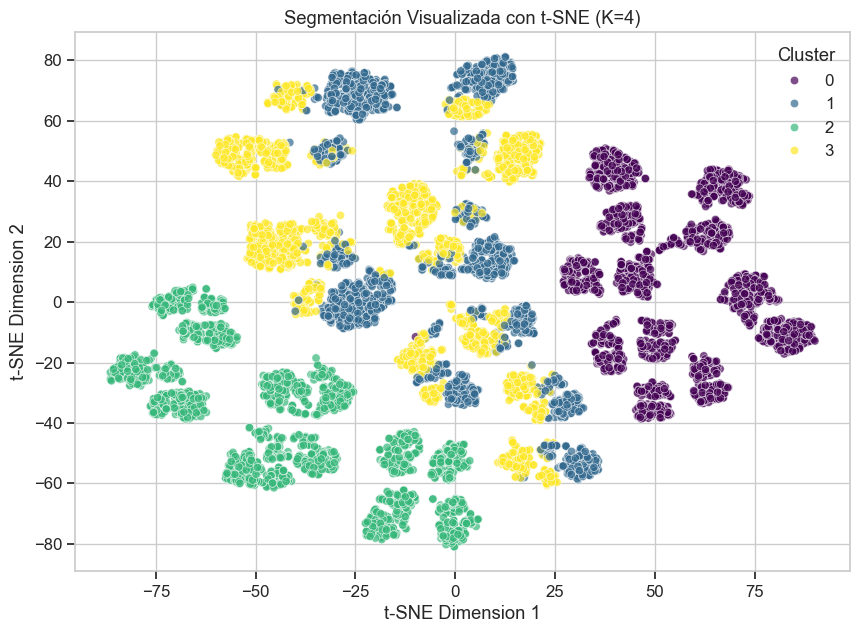

In [150]:
# --- ENTRENAMIENTO FINAL K-MEANS ---
K_OPTIMO = 4 # Seleccionamos 4 basado en la caída de la inercia y estabilidad
kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Agregamos los clusters al DataFrame Original para análisis
df['Cluster_KMeans'] = cluster_labels

# --- VISUALIZACIÓN AVANZADA: t-SNE ---
print("⏳ Calculando t-SNE (puede tardar unos segundos)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['Cluster_KMeans'], palette='viridis', alpha=0.7)
plt.title(f'Segmentación Visualizada con t-SNE (K={K_OPTIMO})')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster')
plt.show()

## 🕵️ 3. Detección de Anomalías: DBSCAN
DBSCAN nos permite identificar clientes "ruido" (Outliers) que no encajan en ningún comportamiento estándar.

In [ ]:

# Aplicación de DBSCAN
# Parámetros iniciales: eps=1.5, min_samples=50
dbscan = DBSCAN(eps=1.5, min_samples=50)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Agregar etiquetas al dataframe
df['Cluster_DBSCAN'] = dbscan_labels

print("📊 Resultados de DBSCAN:")
print(f"Número de clusters encontrados: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Clientes considerados outliers (-1): {(dbscan_labels == -1).sum()}")
print(f"Porcentaje de outliers: {(dbscan_labels == -1).sum()/len(dbscan_labels)*100:.2f}%")


# Distribución de clusters
dbscan_dist = pd.Series(dbscan_labels).value_counts().sort_index()
print("\nDistribución de clusters DBSCAN:")
print(dbscan_dist)


📊 Resultados de DBSCAN:
Número de clusters encontrados: 12
Clientes considerados outliers (-1): 7582
Porcentaje de outliers: 75.82%

Distribución de clusters DBSCAN:
-1     7582
 0      335
 1      228
 2      353
 3      319
 4      120
 5      177
 6      310
 7      177
 8       51
 9      209
 10      78
 11      61
Name: count, dtype: int64


🛑 DBSCAN detectó 40 clientes outliers (0.40% de la base).


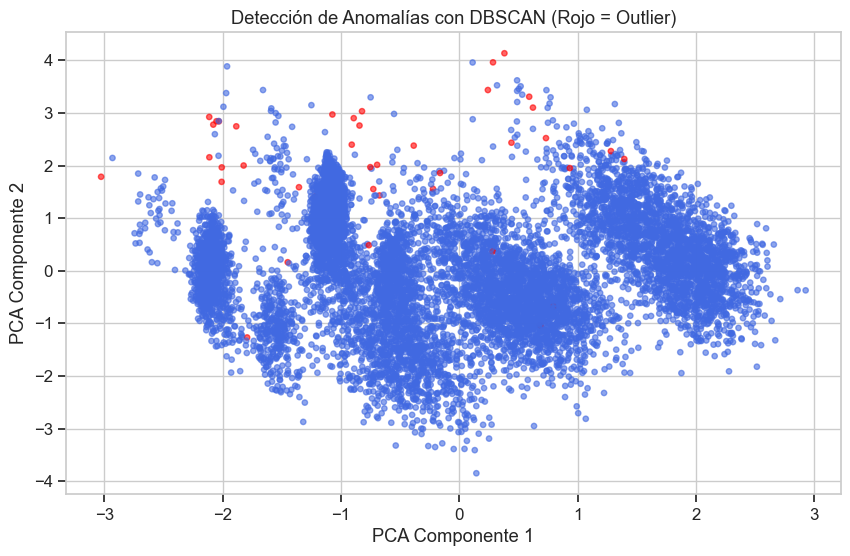

In [164]:
# Configuración de DBSCAN
# eps: radio de vecindad (ajustado empíricamente tras escalar)
# min_samples: mínimo de vecinos para ser 'core point'
dbscan = DBSCAN(eps=2.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Agregamos al DF
df['Cluster_DBSCAN'] = dbscan_labels

# Contamos outliers (-1 son outliers en DBSCAN)
n_outliers = list(dbscan_labels).count(-1)
pct_outliers = n_outliers / len(df) * 100

print(f"🛑 DBSCAN detectó {n_outliers} clientes outliers ({pct_outliers:.2f}% de la base).")

# Visualizamos DBSCAN sobre PCA 2D
plt.figure(figsize=(10, 6))
# Mapeamos colores: Outliers en Rojo, resto en gris/azul
colors = ['red' if x == -1 else 'royalblue' for x in dbscan_labels]
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=colors, s=15, alpha=0.6)
plt.title('Detección de Anomalías con DBSCAN (Rojo = Outlier)')
plt.xlabel('PCA Componente 1')
plt.ylabel('PCA Componente 2')
plt.show()

## 📊 4. Perfilado de Clientes y Estrategias (Business Intelligence)
Analizamos las características de cada cluster de K-Means y aplicamos el motor de recomendaciones.

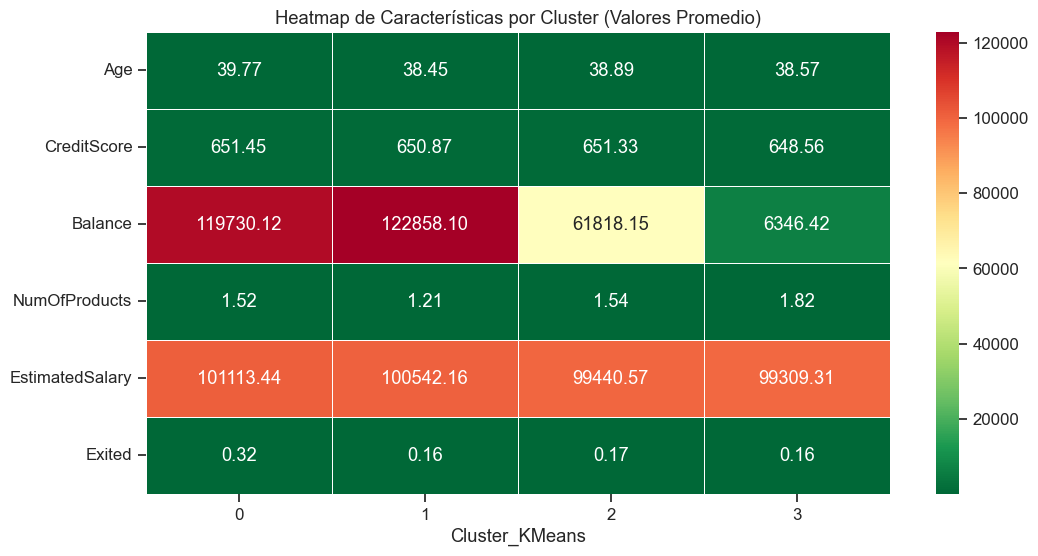

,Age,CreditScore,Balance,NumOfProducts,EstimatedSalary,Exited,Poblacion
Cluster_KMeans,,,,,,,
0,39.771622,651.453567,119730.116134,1.519729,101113.435102,0.324432,2509
1,38.449771,650.874531,122858.101584,1.211338,100542.160521,0.164235,2399
2,38.890997,651.333872,61818.147763,1.539362,99440.572281,0.166734,2477
3,38.568642,648.561759,6346.422099,1.824092,99309.311476,0.159082,2615


In [152]:
# Calculamos las medias por cluster
numeric_cols = ['Age', 'CreditScore', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']
cluster_summary = df.groupby('Cluster_KMeans')[numeric_cols].mean()
cluster_summary['Poblacion'] = df['Cluster_KMeans'].value_counts()

# Heatmap para interpretar visualmente
plt.figure(figsize=(12, 6))
# Normalizamos por columnas para ver qué destaca en cada cluster
sns.heatmap(cluster_summary.iloc[:, :-1].T, cmap="RdYlGn_r", annot=True, fmt=".2f", linewidths=.5)
plt.title('Heatmap de Características por Cluster (Valores Promedio)')
plt.show()

display(cluster_summary)

In [162]:
print("\n" + "="*80)
print("🧠 MOTOR DE ESTRATEGIA FINANCEGUARD (Basado en Segmentación K-Means)")
print("="*80 + "\n")

for cluster_id, row in cluster_summary.iterrows():
    churn = row['Exited']
    count = row['Poblacion']
    
    print(f"🔵 CLUSTER {cluster_id} | Clientes: {int(count)} | Tasa de Abandono (Churn): {churn:.1%}")
    
    if churn > 0.35:
        print("   🚨 ESTADO: CRÍTICO (Muy Alto Riesgo)")
        print("   🔍 Diagnóstico: Posible insatisfacción grave o mejores ofertas de competencia.")
        print("   ⚔️ ACCIONES RECOMENDADAS:")
        print("      • Contacto telefónico prioritario para retención.")
        print("      • Ofrecer descuento agresivo en comisiones (3-6 meses).")
    
    elif churn > 0.20:
        print("   ⚠️ ESTADO: RIESGO ALTO (Promedio del banco o superior)")
        print("   🔍 Diagnóstico: Clientes sensibles al precio o servicio.")
        print("   🛡️ ACCIONES RECOMENDADAS:")
        print("      • Campaña de Email Marketing con beneficios de fidelidad.")
        print("      • Revisar si tienen productos inactivos.")
        
    elif churn > 0.10:
        print("   😐 ESTADO: RIESGO MODERADO")
        print("   🔍 Diagnóstico: Comportamiento estable, riesgo latente.")
        print("   🛡️ ACCIONES RECOMENDADAS:")
        print("      • Cross-selling suave (seguros, inversiones).")
        print("      • Encuestas de satisfacción.")
        
    else:
        print("   ✅ ESTADO: CLIENTES LEALES")
        print("   🔍 Diagnóstico: Alta fidelidad, promotores de marca.")
        print("   📈 ACCIONES RECOMENDADAS:")
        print("      • Programa de Referidos (Trae a un amigo).")
        print("      • Ofrecer productos Premium/VIP.")
        
    print("-" * 80)


🧠 MOTOR DE ESTRATEGIA FINANCEGUARD (Basado en Segmentación K-Means)

🔵 CLUSTER 0 | Clientes: 2509 | Tasa de Abandono (Churn): 32.4%
   ⚠️ ESTADO: RIESGO ALTO (Promedio del banco o superior)
   🔍 Diagnóstico: Clientes sensibles al precio o servicio.
   🛡️ ACCIONES RECOMENDADAS:
      • Campaña de Email Marketing con beneficios de fidelidad.
      • Revisar si tienen productos inactivos.
--------------------------------------------------------------------------------
🔵 CLUSTER 1 | Clientes: 2399 | Tasa de Abandono (Churn): 16.4%
   😐 ESTADO: RIESGO MODERADO
   🔍 Diagnóstico: Comportamiento estable, riesgo latente.
   🛡️ ACCIONES RECOMENDADAS:
      • Cross-selling suave (seguros, inversiones).
      • Encuestas de satisfacción.
--------------------------------------------------------------------------------
🔵 CLUSTER 2 | Clientes: 2477 | Tasa de Abandono (Churn): 16.7%
   😐 ESTADO: RIESGO MODERADO
   🔍 Diagnóstico: Comportamiento estable, riesgo latente.
   🛡️ ACCIONES RECOMENDADAS:
   

In [161]:
# Guardamos el dataset enriquecido
# "Usa estos insights para mejorar el feature engineering"
df.to_csv('Churn_Modelling_Clusters.csv', index=False)
print("💾 Archivo 'Churn_Modelling_Clusters.csv' guardado con éxito.")

💾 Archivo 'Churn_Modelling_Clusters.csv' guardado con éxito.
